<a href="https://colab.research.google.com/github/Pranayshukla0610/ML-projects-portfolio/blob/main/Real_Time_Equity_Market_Analytics%2C_Volatility_Modeling_%26_Stock_Return_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
pip install pandas numpy matplotlib seaborn yfinance plotly scikit-learn xgboost ta statsmodels

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from ta.volatility import BollingerBands
from ta.momentum import RSIIndicator
from ta.trend import MACD

import warnings
warnings.filterwarnings('ignore')

In [20]:
ticker = 'AAPL'

df = yf.download(
    ticker,
    start = '2020-01-01',
    end = '2026-01-01'
)

[*********************100%***********************]  1 of 1 completed


In [21]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400536,72.460799,71.156697,71.409800,135480400
2020-01-03,71.696632,72.455950,71.472454,71.629138,146322800
2020-01-06,72.267929,72.306499,70.568503,70.819201,118387200
2020-01-07,71.928040,72.533080,71.708680,72.277563,108872000
2020-01-08,73.085098,73.386416,71.631544,71.631544,132079200


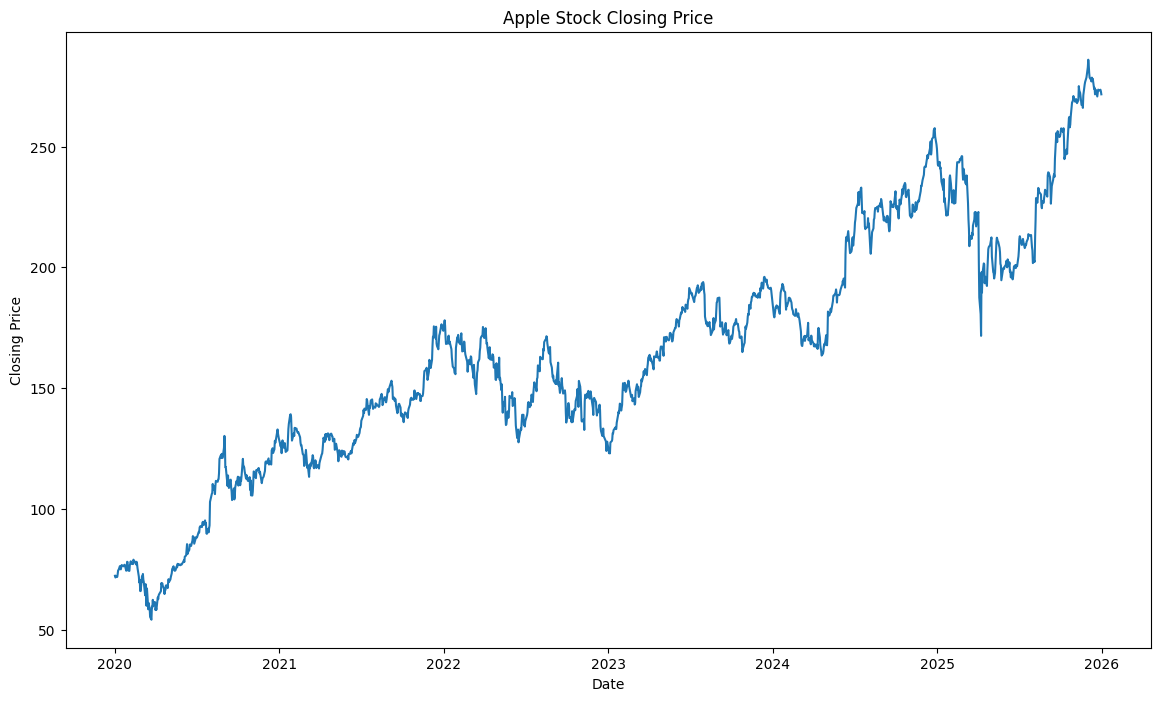

In [22]:
plt.figure(figsize=(14,8))

sns.lineplot(
    x = df.index,
    y=df['Close'].squeeze()
)

plt.title('Apple Stock Closing Price')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.show()

In [23]:
df['Daily Return'] = (df['Close'].pct_change())

In [24]:
df.head()

Price,Close,High,Low,Open,Volume,Daily Return
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,
2020-01-02,72.400536,72.460799,71.156697,71.409800,135480400,NaN
2020-01-03,71.696632,72.455950,71.472454,71.629138,146322800,-0.009722
2020-01-06,72.267929,72.306499,70.568503,70.819201,118387200,0.007968
2020-01-07,71.928040,72.533080,71.708680,72.277563,108872000,-0.004703
2020-01-08,73.085098,73.386416,71.631544,71.631544,132079200,0.016086


Text(0, 0.5, 'Frequency')

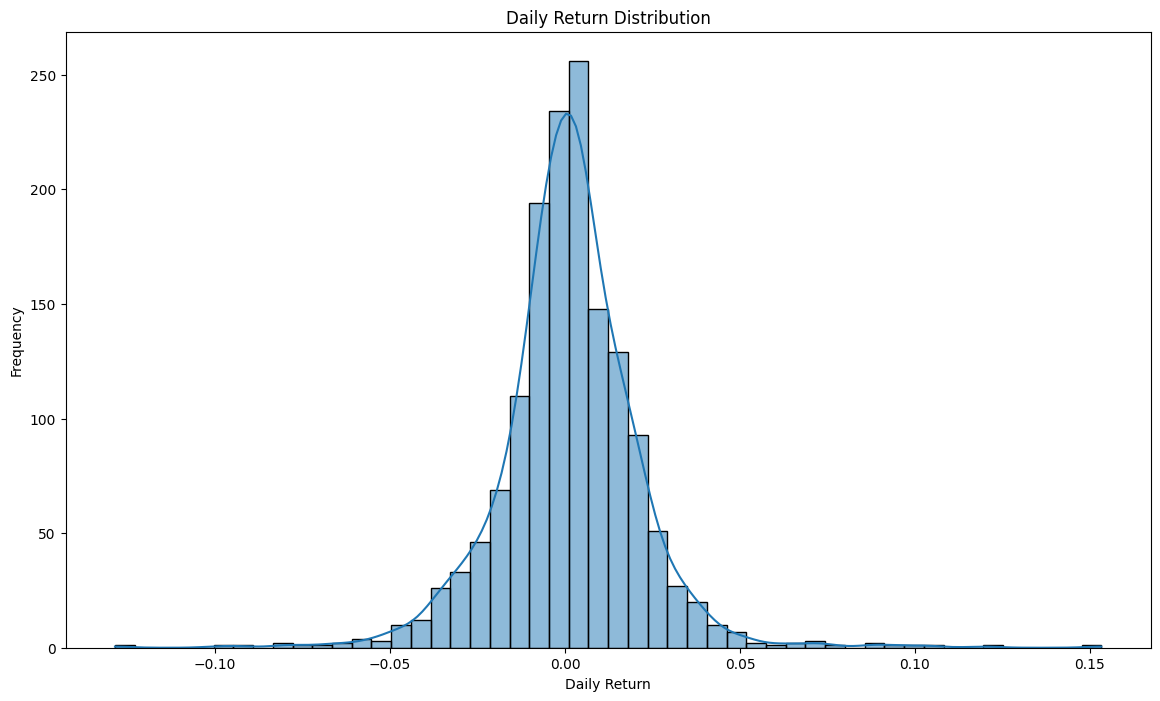

In [25]:
plt.figure(figsize=(14,8))

sns.histplot(
    df['Daily Return'],
    kde=True,
    bins=50
)

plt.title('Daily Return Distribution')
plt.xlabel('Daily Return')
plt.ylabel('Frequency'
)

In [26]:
df['Volatility'] = (
    df['Daily Return'].rolling(30).std()
)

In [27]:
df.head()

Price,Close,High,Low,Open,Volume,Daily Return,Volatility
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,
Date,,,,,,,
2020-01-02,72.400536,72.460799,71.156697,71.409800,135480400,NaN,NaN
2020-01-03,71.696632,72.455950,71.472454,71.629138,146322800,-0.009722,NaN
2020-01-06,72.267929,72.306499,70.568503,70.819201,118387200,0.007968,NaN
2020-01-07,71.928040,72.533080,71.708680,72.277563,108872000,-0.004703,NaN
2020-01-08,73.085098,73.386416,71.631544,71.631544,132079200,0.016086,NaN


Text(0, 0.5, 'Volatility')

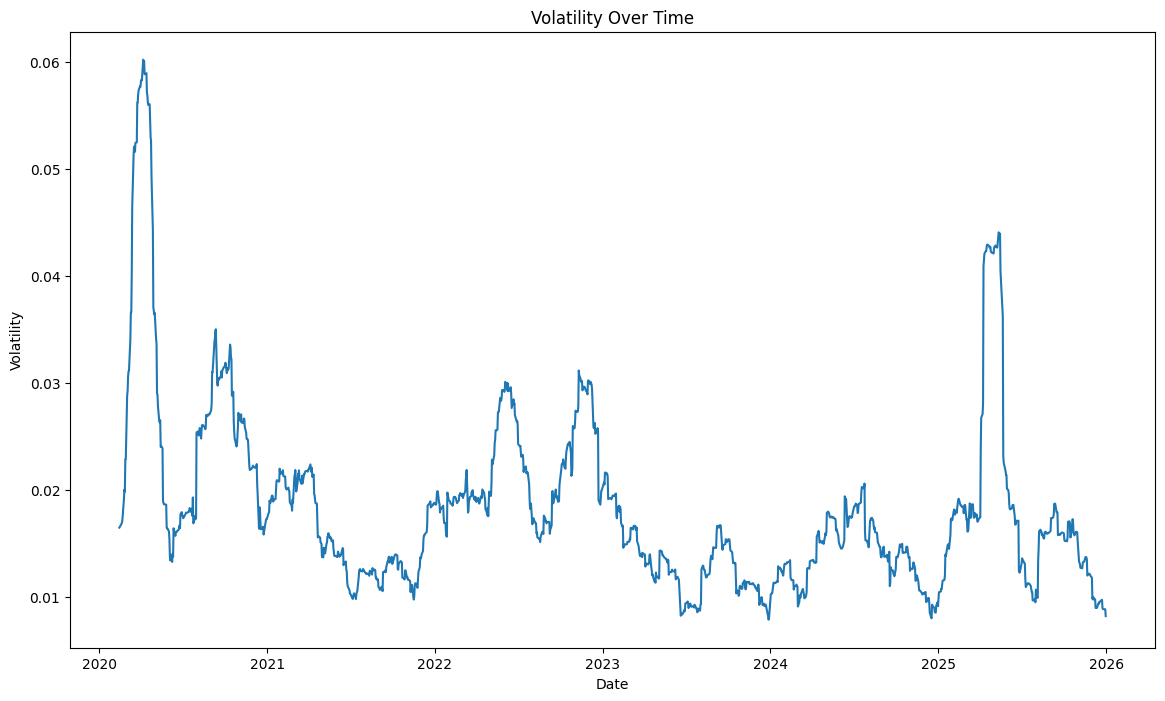

In [28]:
plt.figure(figsize=(14,8))

sns.lineplot(x=df.index, y=df['Volatility'])

plt.title('Volatility Over Time')
plt.xlabel('Date')
plt.ylabel('Volatility')

In [29]:
stocks = ['AAPL','MSFT','GOOGL','NVDA']

prices = yf.download(
    stocks,
    start = '2020-01-01'
)['Close']

[*********************100%***********************]  4 of 4 completed


In [30]:
returns = prices.pct_change()

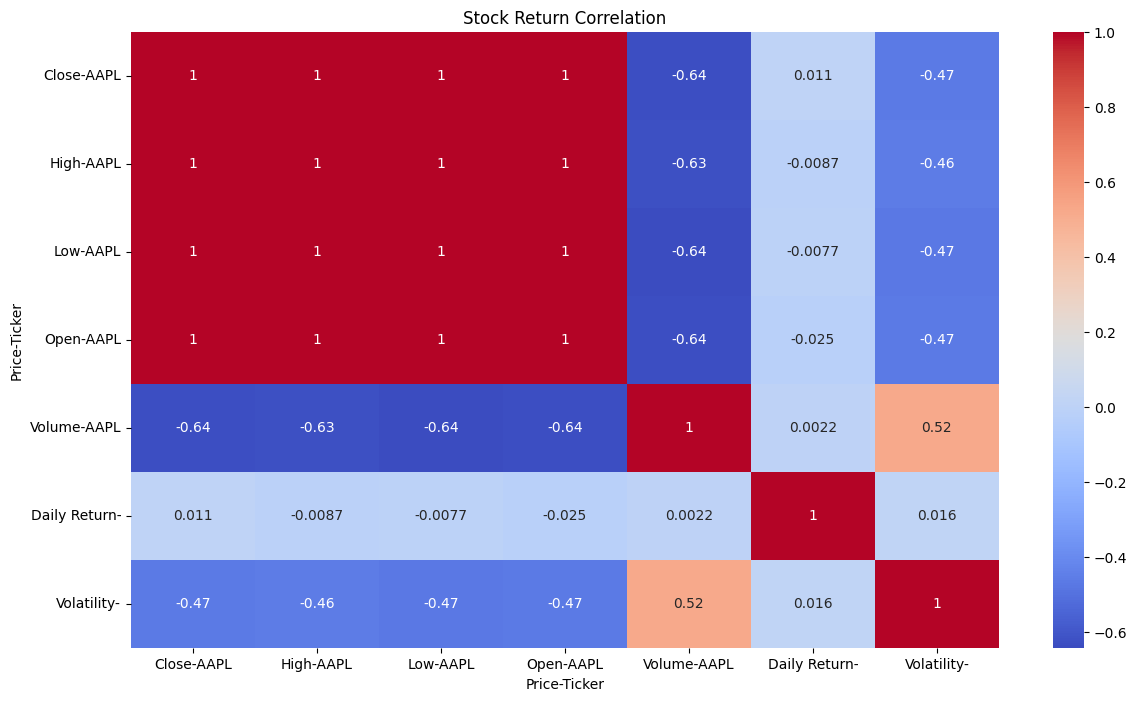

In [31]:
plt.figure(figsize=(14,8))

sns.heatmap(df.corr(),annot=True,cmap='coolwarm')

plt.title('Stock Return Correlation')
plt.show()

In [32]:
df['MA50'] = df['Close'].rolling(50).mean()
df['MA200'] = df['Close'].rolling(200).mean()

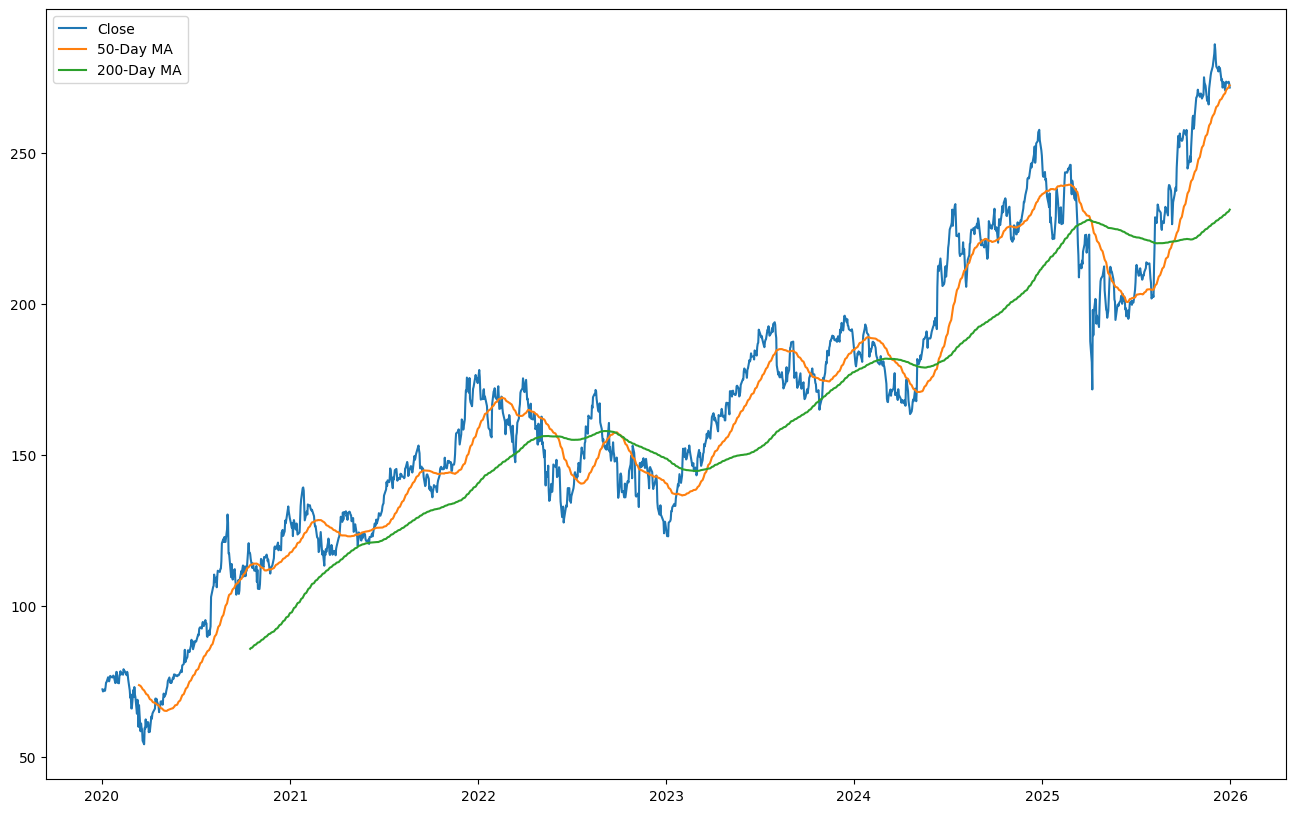

In [33]:
plt.figure(figsize=(16,10))

plt.plot(df['Close'],label='Close')

plt.plot(df['MA50'],label='50-Day MA')

plt.plot(df['MA200'],label='200-Day MA')

plt.legend()

plt.show()

In [37]:
rsi = RSIIndicator(df['Close'].squeeze())
df['RSI'] = rsi.rsi()

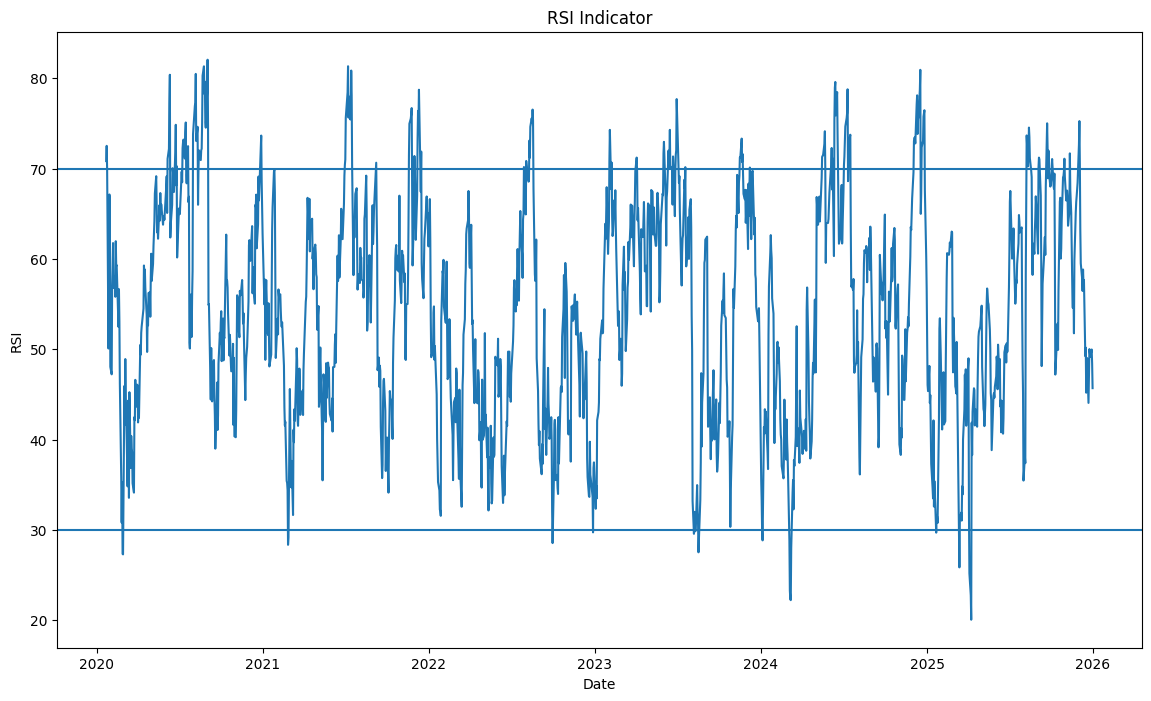

In [38]:
plt.figure(figsize=(14,8))

sns.lineplot(
    x = df.index,
    y = df['RSI']
)

plt.axhline(70)
plt.axhline(30)

plt.title('RSI Indicator')
plt.show()

In [40]:
bb = BollingerBands(df['Close'].squeeze())

df['BB_High'] = bb.bollinger_hband()
df['BB_Low'] = bb.bollinger_lband()

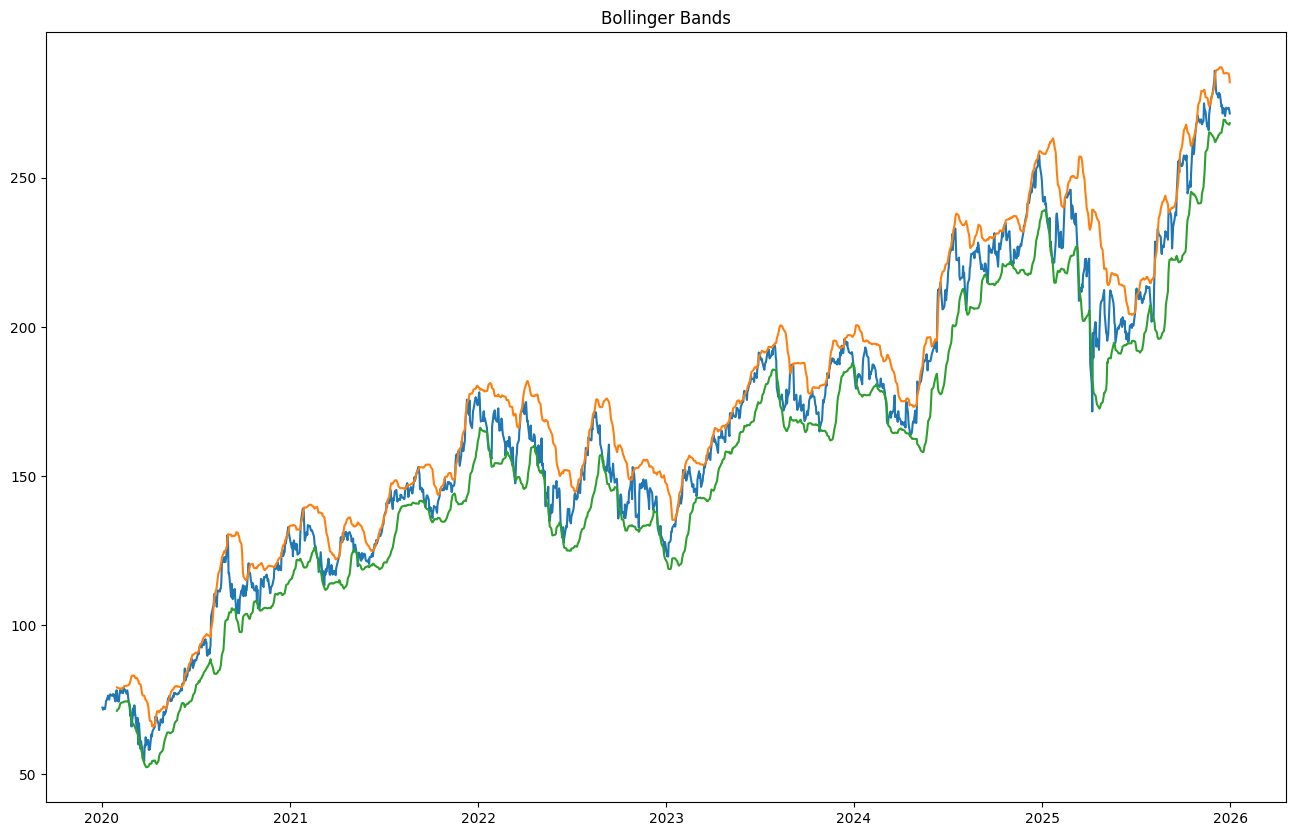

In [41]:
plt.figure(figsize=(16,10))

plt.plot(df['Close'])

plt.plot(df['BB_High'])

plt.plot(df['BB_Low'])

plt.title('Bollinger Bands')

plt.show()

In [42]:
df['Lag_1'] = df['Close'].shift(1)

df['Lag_7'] = df['Close'].shift(7)

df['Lag_30'] = df['Close'].shift(30)

In [44]:
features = [
    'Volume',
    'Volatility',
    'MA50',
    'MA200',
    'RSI',
    'Lag_1',
    'Lag_7',
    'Lag_30'
]

X = df[features]

y = df['Close']

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [53]:
X_train = X_train.dropna()
y_train = y_train.loc[X_train.index]

In [54]:
lr = LinearRegression()

lr.fit(X_train,y_train)

LinearRegression()

In [55]:
lr_pred = lr.predict(X_test)

In [56]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

rf.fit(X_train,y_train)

RandomForestRegressor(max_depth=10, n_estimators=300, random_state=42)

In [57]:
rf_pred = rf.predict(X_test)

In [58]:
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [59]:
def evaluate_model(y_true, pred, model_name):

    print(f"\n{model_name}")

    print(
        "MAE:",
        mean_absolute_error(y_true, pred)
    )

    print(
        "RMSE:",
        np.sqrt(mean_squared_error(y_true, pred))
    )

    print(
        "R2:",
        r2_score(y_true, pred)
    )

In [60]:
evaluate_model(y_test, lr_pred, 'Linear Regression')

evaluate_model(y_test, rf_pred, 'Random Forest')

evaluate_model(y_test, xgb_pred, 'XGBoost')


Linear Regression
MAE: 2.091457774058342
RMSE: 3.407790881866376
R2: 0.9808572153998172

Random Forest
MAE: 14.107855376169232
RMSE: 20.748317004680295
R2: 0.290381402240807

XGBoost
MAE: 14.602227210998535
RMSE: 20.786580760126608
R2: 0.2877616286277771


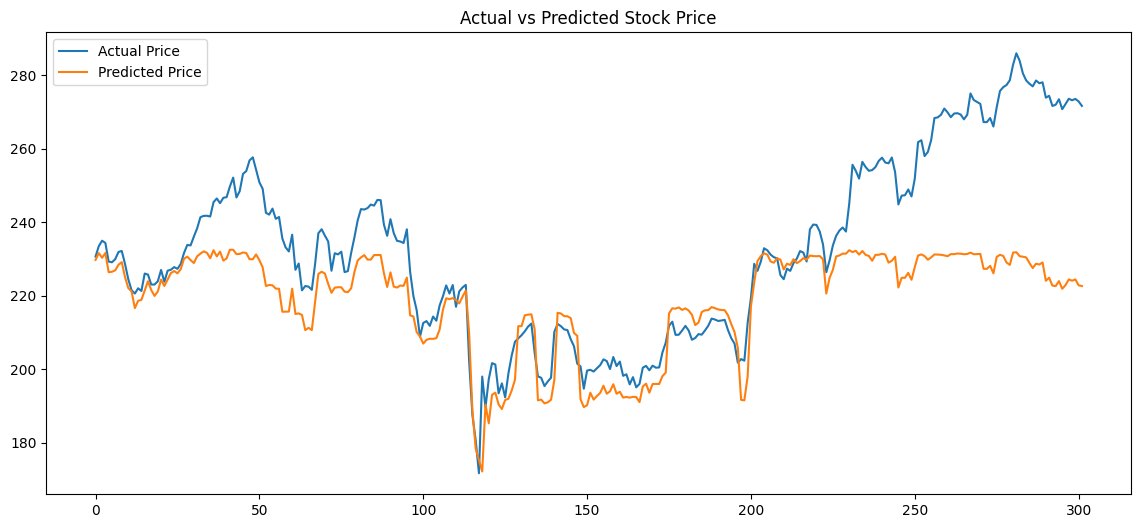

In [61]:
plt.figure(figsize=(14,6))

plt.plot(
    y_test.values,
    label='Actual Price'
)

plt.plot(
    xgb_pred,
    label='Predicted Price'
)

plt.legend()

plt.title('Actual vs Predicted Stock Price')

plt.show()

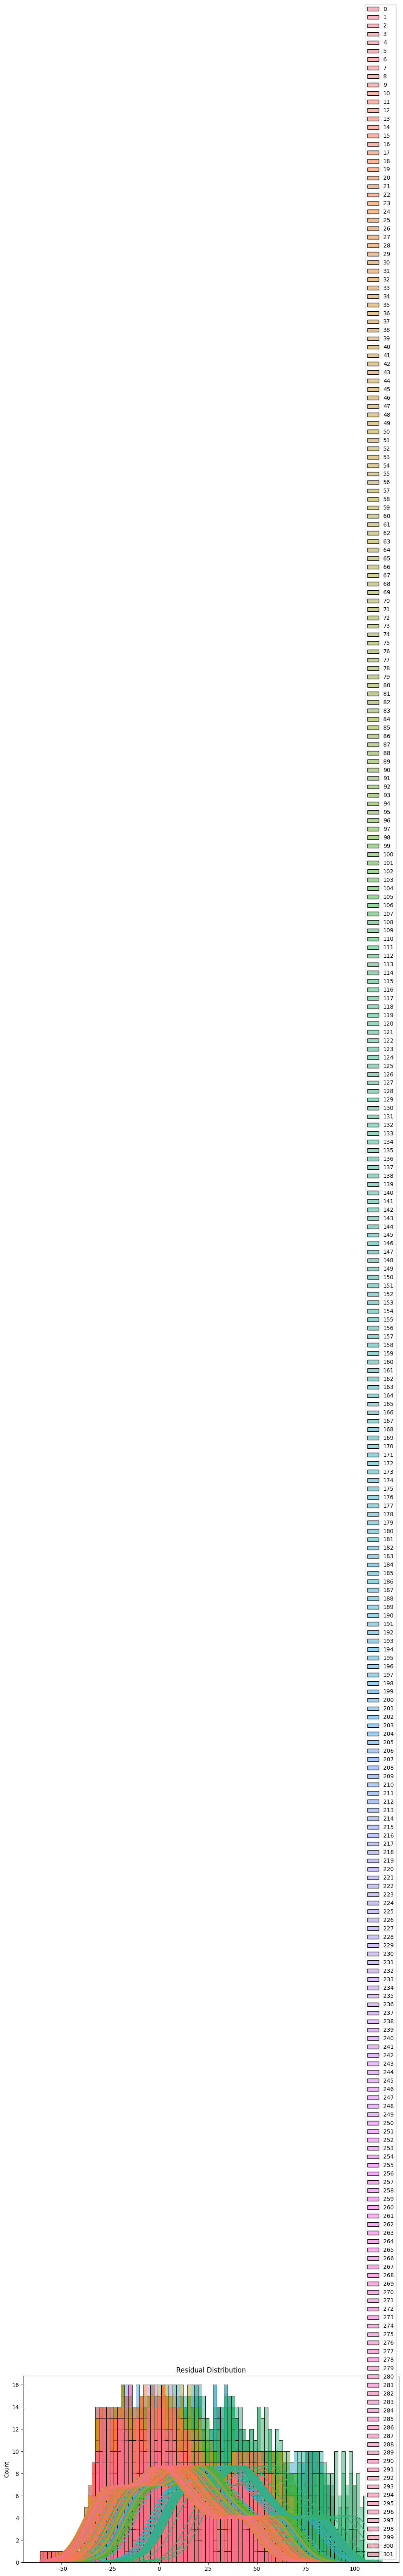

In [62]:
residuals = y_test.values - xgb_pred

plt.figure(figsize=(12,6))

sns.histplot(
    residuals,
    kde=True
)

plt.title('Residual Distribution')

plt.show()

In [63]:
importance = pd.DataFrame({
    'Feature': features,
    'Importance': xgb.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

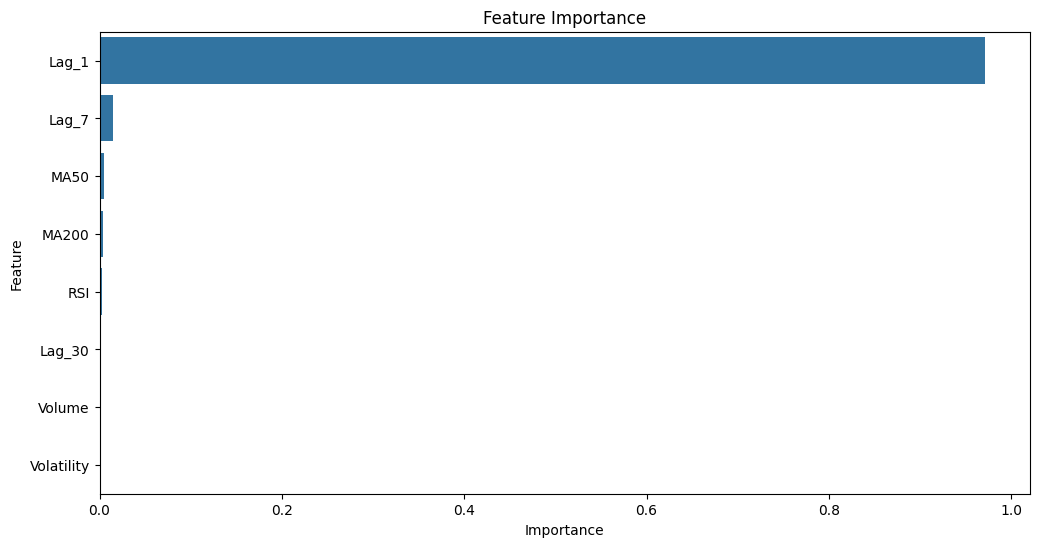

In [64]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title('Feature Importance')

plt.show()

In [66]:
fig = go.Figure(data=[
    go.Candlestick(
        x=df.index,
        open = df['Open'],
        high = df['High'],
        low = df['Low'],
        close = df['Close']
    )
])

fig.update_layout(
    title = 'Candlestick Chart'
)

fig.show()

In [68]:
df.head()

Price,Close,High,Low,Open,Volume,Daily Return,Volatility,MA50,MA200,RSI,BB_High,BB_Low,Lag_1,Lag_7,Lag_30
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,,,,,,
Date,,,,,,,,,,,,,,,
2020-01-02,72.400536,72.460799,71.156697,71.409800,135480400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-03,71.696632,72.455950,71.472454,71.629138,146322800,-0.009722,NaN,NaN,NaN,NaN,NaN,NaN,72.400536,NaN,NaN
2020-01-06,72.267929,72.306499,70.568503,70.819201,118387200,0.007968,NaN,NaN,NaN,NaN,NaN,NaN,71.696632,NaN,NaN
2020-01-07,71.928040,72.533080,71.708680,72.277563,108872000,-0.004703,NaN,NaN,NaN,NaN,NaN,NaN,72.267929,NaN,NaN
2020-01-08,73.085098,73.386416,71.631544,71.631544,132079200,0.016086,NaN,NaN,NaN,NaN,NaN,NaN,71.928040,NaN,NaN


In [70]:
mean_return = df['Daily Return'].mean()

std_return = df['Daily Return'].std()

VaR_95 = mean_return - 1.65 * std_return

print("95% Value at Risk:", VaR_95)

95% Value at Risk: -0.03198513143967893


###There is a 95% confidence that your portfolio/stock will NOT lose more than 3.19% in a single day.

In [72]:
sharpe_ratio = (
    df['Daily Return'].mean() /
    df['Daily Return'].std()
) * np.sqrt(252)

print("Sharpe Ratio:", sharpe_ratio)

Sharpe Ratio: 0.8537979426949809
